In [64]:
import functools
from pathlib import Path
import itertools
from tqdm import tqdm
from typing import Literal, Union

import scvi
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from sklearn.metrics.pairwise import cosine_similarity
from anndata import AnnData
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings("ignore")

In [59]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import cosine_distances
def align_factors_3d(W_array, axis=0):
    """
    Aligns factors along a specified axis using the Hungarian algorithm.
    
    Parameters:
    W_array: ndarray of shape (num_runs, n_samples, n_components).
    axis: Axis along which to align factors (default: 0 for multiple runs of NMF).

    Returns:
    Aligned W_array of the same shape.
    """
    if axis != 0:
        raise NotImplementedError("Only axis=0 is currently supported.")

    num_runs, n_samples, n_components = W_array.shape
    reference_W = W_array[0]  # Use the first W as reference
    aligned_W_array = np.empty_like(W_array)
    aligned_W_array[0] = reference_W  # Keep the first as is

    for i in range(1, num_runs):
        W = W_array[i]

        # Compute cost matrix (cosine distances between factors)
        cost_matrix = cosine_distances(reference_W.T, W.T)  # (n_components, n_components)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        # Reorder the components based on the Hungarian algorithm
        aligned_W_array[i] = W[:, col_ind]  # Align components

    return aligned_W_array

In [60]:
# Reading spatial Query Dataset (as a counts csv) and annotate with the nico generated annotation adata object
adata_sp = (lambda f: lambda counts_csv_path, adata_annotation_path: f(sc.read(counts_csv_path).transpose(), sc.read_h5ad(adata_annotation_path)))(
    lambda adata, adata_annotation: sc.AnnData(X=adata.X, obs=adata.obs.join(adata_annotation.obs, how="outer"), var=adata.var)
)(counts_csv_path=Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
  adata_annotation_path=Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad")

# Reading single cell reference dataset
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")

sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)

shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names

print(f"{len(shared_genes)=}")

len(shared_genes)=203


In [61]:
adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


1it [05:14, 314.02s/it]
5it [00:26,  5.25s/it]
5it [00:25,  5.11s/it]
5it [00:25,  5.11s/it]
5it [00:27,  5.41s/it]
5it [00:28,  5.60s/it]
5it [00:29,  5.81s/it]
5it [00:29,  5.94s/it]
5it [00:29,  5.98s/it]
5it [00:27,  5.55s/it]
5it [00:25,  5.11s/it]


(0.0, 1.0)

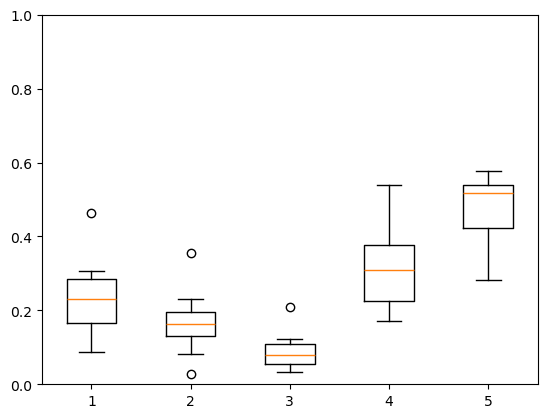

In [191]:
def nmf_transfer(
        adata_query: AnnData,
        adata_reference: AnnData,
        shared_genes_mask_reference: np.ndarray,
        gene_filter_mask: np.ndarray | None = None,
        n_components: int | None = None,
        nmf_func: callable = non_negative_factorization,
        W_init_reference: np.ndarray | None = None,
        H_init_reference: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    shared_genes = adata_reference[:, shared_genes_mask_reference].var_names

    if gene_filter_mask is None:
        gene_filter_mask = np.ones(len(shared_genes), dtype=bool)

    init_reference = "custom" if W_init_reference is not None or H_init_reference is not None else None

    if W_init_reference is not None:
        W_init_reference = W_init_reference.copy(order="C")

    W, H, _, W_init, H_init = (
        lambda W_init, H_init, _: (
            *nmf_func(
                adata_query[:, shared_genes][:, gene_filter_mask].X.toarray(),
                H=H_init[:, gene_filter_mask],
                init="custom",
                update_H=False
            ),
            W_init,
            H_init)
        )(
            *nmf_func(
                adata_reference[:, shared_genes_mask_reference].X.toarray(),
                init=init_reference,
                W=W_init_reference,
                H=H_init_reference,
                n_components=n_components
            )
        )
    return W, H, W_init, H_init

test = [(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components_range, shared_genes, celltypes: pd.DataFrame(
        [
            (
                celltype,
                n_components,
                pearsonr(
                    np.mean(
                        adata_query[:, shared_genes].X,
                        axis=0
                    ),
                    np.mean(
                        np.hstack(
                            [
                                (lambda W, H, W_init, H_init, arg: W @ H_init[:, ~arg])(
                                    *(lambda func, arg: (*func(arg), arg))(
                                        functools.partial(
                                            nmf_transfer,
                                            adata_query[adata_query.obs["celltype"] == celltype],
                                            adata_reference[adata_reference.obs["celltype"] == celltype],
                                            shared_genes_mask_reference,
                                            n_components=n_components),
                                        ~np.isin(shared_genes, gene)
                                    )
                                )
                                for gene in shared_genes
                            ]
                        ),
                        axis=0
                    )
                )[0]
            )
        for celltype, n_components in tqdm(itertools.product(celltypes, n_components_range))]
    )
)(
    adata_sp,
    adata_sc,
    shared_genes_mask_sc,
    n_components_range=[2, 3, 4, 6, 8],
    shared_genes=shared_genes,
    celltypes=["Stem/TA"]
).pivot(index=1, columns=0, values=2).values for adata_sp in (lambda adata, n: [adata[np.random.choice(adata.n_obs, 50)] for _ in range(n)])(adata_sp, 10)]
plt.boxplot(np.array(test).squeeze())
plt.ylim(0, 1)

In [ ]:
adata_sp

(0.0, 1.0)

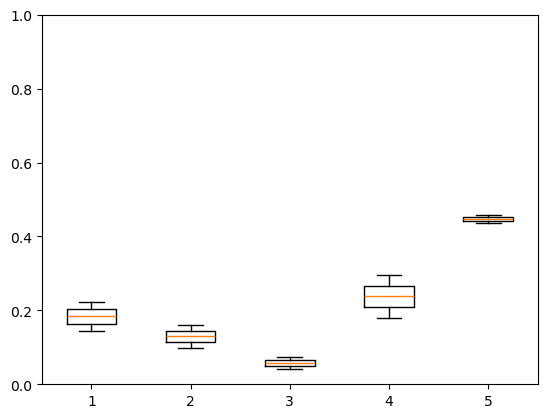

In [190]:
plt.boxplot(np.array(test).squeeze())
plt.ylim(0, 1)

ValueError: X must have 2 or fewer dimensions

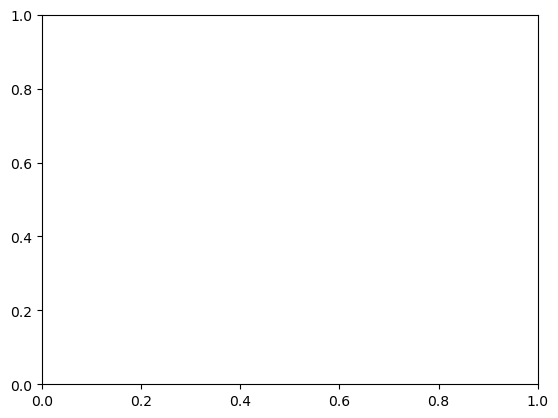

In [183]:
plt.boxplot(test)

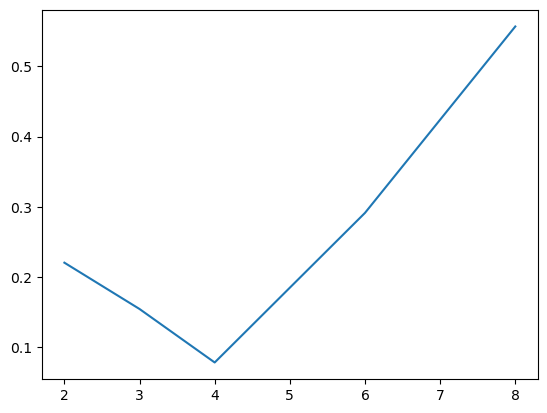

In [180]:
plt.plot(test.pivot(index=1, columns=0, values=2))

In [62]:
nmf_transfer = (lambda get_index_array: lambda nmf_2, nmf_1: lambda adata_query, adata_reference, n_components: (lambda shared_genes: nmf_2(
    X=adata_query[:, get_index_array(adata_query, shared_genes)].X, 
    H_init=nmf_1(adata_reference[:, get_index_array(adata_reference, shared_genes)].X, n_components)
))(
    set(adata_query.var_names) & set(adata_reference.var_names))
)(
    lambda adata, shared_genes: adata.var_names.get_indexer_for(shared_genes)
)(
    nmf_2=lambda X, H_init: non_negative_factorization(X, H=H_init, init="custom", update_H=False),
    nmf_1=lambda X, n_components: non_negative_factorization(X, n_components=n_components)[1],
)

bootstrap_adatas = (
    lambda adata_query, adata_reference, n: itertools.starmap(
        (lambda f: lambda a, b: (f(a), f(b)))(
            lambda adata: adata[np.random.choice(adata.n_obs, adata.n_obs)]
        ), 
        itertools.repeat((adata_query, adata_reference), n)
    )
)



(0.0, 1.0)

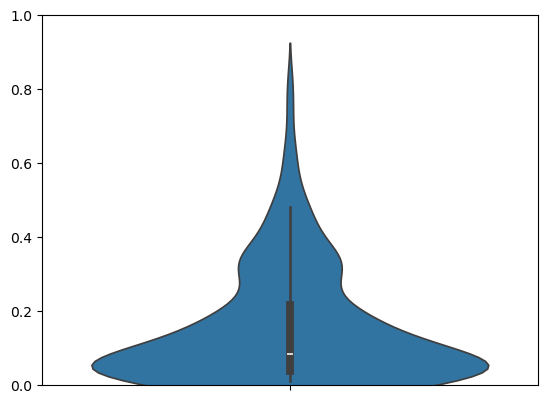

In [69]:
n_components=3
test = align_factors_3d(np.array([nmf_transfer(adata_query, adata_reference, n_components=n_components)[1] for adata_query, adata_reference in bootstrap_adatas(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], 20)]))
sns.violinplot(np.array([cosine_similarity(test[i], test[j])[np.eye(n_components, dtype=bool)].mean() for i, j in itertools.combinations(range(test.shape[0]), 2)]))
plt.ylim(0,1)

In [89]:
(lambda arr: cosine_similarity(arr))(np.random.choice(100, (5,20)))

array([[1.        , 0.73188015, 0.73219129, 0.85844215, 0.84071137],
       [0.73188015, 1.        , 0.68190981, 0.62958375, 0.68755122],
       [0.73219129, 0.68190981, 1.        , 0.79276956, 0.84723857],
       [0.85844215, 0.62958375, 0.79276956, 1.        , 0.77880565],
       [0.84071137, 0.68755122, 0.84723857, 0.77880565, 1.        ]])

In [125]:
import math
np.sum(np.arange(1, 5))

np.int64(10)

(0.0, 1.0)

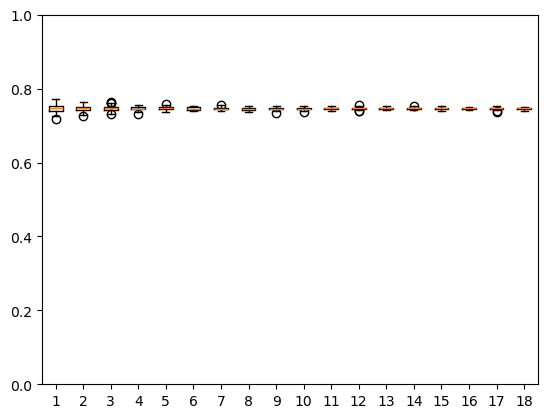

In [146]:
plt.boxplot(np.array([np.array([(lambda n: np.triu(cosine_similarity(np.random.choice(100, (n, 1000))), k=1).sum() / np.sum(np.arange(1, n)))(n) for n in range(2, 20)]) for _ in range(100)]))
plt.ylim(0, 1)

In [83]:
np.random.choice(100, 5)

array([78, 60, 71, 34, 97])

In [72]:
(lambda nmf_res: nmf_res[0] @ nmf_res[1])(non_negative_factorization(adata_sc[:, shared_genes].X, n_components=3))

array([[1.9863563e-02, 4.3315319e-03, 2.6749086e-01, ..., 1.2560388e-02,
        1.4750279e-03, 2.5324282e-01],
       [1.8836735e-02, 8.6905491e-03, 3.5570878e-01, ..., 2.6844606e-02,
        2.1247095e-03, 5.3345507e-01],
       [4.7197908e-02, 2.2320308e-02, 9.2254812e-01, ..., 7.1963377e-02,
        2.9601529e-03, 1.4387802e+00],
       ...,
       [9.1560622e-04, 1.3853585e-04, 9.0203425e-03, ..., 8.2000137e-05,
        3.0774853e-04, 9.1318454e-04],
       [1.6873235e-02, 3.0924330e-04, 1.5487456e-01, ..., 9.9565586e-05,
        3.7411417e-04, 8.9007653e-03],
       [5.3988013e-04, 1.4827054e-04, 5.6551970e-03, ..., 9.0149304e-05,
        3.3873279e-04, 7.7164121e-04]], dtype=float32)

In [277]:
pd.DataFrame(cosine_similarity(test[0], test[1]))

,0,1
0,0.999962,0.003594
1,0.007268,0.999022


In [197]:
for i, j in itertools.combinations(range(test.shape[0]), 2):
    print(i, j)

0 1
0 2
0 3
1 2
1 3
2 3


In [ ]:
np.apply_along_axis(cosine)

In [200]:
test[1].shape

(3, 203)

In [191]:
test.shape

(4, 3, 203)

In [194]:
list(itertools.combinations(range(4), 2))

[(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]

In [187]:
np.array(list(itertools.combinations(test, 2))).shape

(6, 2, 3, 203)

In [185]:
arr = np.random.rand(3, 5, 4)  # Shape (3, 5, 4)

axis = 1  # Pairwise along this axis

moved = np.moveaxis(arr, axis, 0)  # Move the axis to 0 for pairing
pairwise_combinations = np.array(list(itertools.combinations(moved, 2)))

print(pairwise_combinations.shape)  # (10, 2, 3, 4) if axis=1

(10, 2, 3, 4)


In [5]:
# This function should only return the W matrix of the second NMF for the purpose of repeatedly running it on bootstrapped data and correlating the W matrices with eachother
nmf_transfer_2= (
    lambda nmf1, nmf2: lambda adata_query, adata_reference, shared_genes_mask_reference, shared_genes, n_components: 
        nmf2(
            adata_query[:, shared_genes].X, 
            nmf1(adata_reference[:, shared_genes_mask_reference].X, n_components)[1],
        )
)(
    lambda X, n_components: non_negative_factorization(X, n_components=n_components), 
    lambda X, H_init: non_negative_factorization(X, H=H_init, init="custom", update_H=False)
)

bootstrap_adatas = (
    lambda adata_query, adata_reference, n: itertools.starmap(
        (lambda f: lambda a, b: (f(a), f(b)))(lambda adata: adata[np.random.choice(adata.n_obs, adata.n_obs)]), 
        itertools.repeat((adata_query, adata_reference), n)
    )
)


bootstrap_nmf_Hs = (
    lambda adata_query, adata_reference, n: np.stack(
        [nmf_transfer_2(adata_query, adata_reference, shared_genes_mask_sc, shared_genes, n_components=3)[1] 
         for adata_query, adata_reference in bootstrap_adatas(adata_query, adata_reference, n)]
    )
)

#test = (lambda f, g: lambda adata_query, adata_reference, n: f(g(adata_query, adata_reference, n)))(
#    align_factors_3d,
#    bootstrap_nmf_Ws
#)(
#    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"],
#    adata_sc[adata_sc.obs["celltype"] == "Stem/TA"],
#    5
#)

In [28]:
bootstrap_nmf_Hs(adata_sp, adata_sc, 5)

array([[[1.32836867e-03, 1.59735489e-03, 3.48037519e-02, ...,
         1.56338699e-03, 0.00000000e+00, 2.06043255e-02],
        [1.93267450e-01, 2.08088825e-03, 1.68368018e+00, ...,
         0.00000000e+00, 0.00000000e+00, 1.21870585e-01],
        [1.48223452e-02, 1.40307033e-02, 1.99831679e-01, ...,
         6.58228528e-03, 2.77337972e-02, 3.19995135e-02]],

       [[0.00000000e+00, 1.05683308e-03, 3.01321619e-03, ...,
         1.01575593e-03, 0.00000000e+00, 3.33856679e-02],
        [1.83843151e-01, 5.84135705e-04, 1.53558540e+00, ...,
         0.00000000e+00, 0.00000000e+00, 4.51372340e-02],
        [6.27052709e-02, 6.74289186e-03, 7.65971839e-01, ...,
         6.80659292e-03, 2.81116161e-02, 2.20514283e-01]],

       [[2.03312578e-04, 3.84441111e-04, 9.91857890e-03, ...,
         1.25864416e-03, 0.00000000e+00, 2.42655445e-02],
        [1.76971391e-01, 0.00000000e+00, 1.58386505e+00, ...,
         0.00000000e+00, 0.00000000e+00, 6.75853863e-02],
        [6.65725842e-02, 1.05563318e